In [1]:
from pathlib import Path

In [2]:
import numpy as np
import pandas as pd

In [3]:
from aeon.transformations.collection import Normalizer
from aeon.classification.distance_based import ProximityForest
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, accuracy_score

In [4]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')
train['action'] = train['genre'].map(lambda x: 'Action' in x)
train_X = (train[[str(i) for i in range(100)]]
           .reset_index()
           .melt(id_vars='id', var_name='time'))
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])
train_X = train_X.sort_index().values.reshape((850, 1, 100))

In [5]:
train_y = train['rating_category']
train_X.shape, train_y.shape

((850, 1, 100), (850,))

In [6]:
test = pd.read_csv(data_dir / 'test_ts.csv', index_col='id')
test['action'] = test['genre'].map(lambda x: 'Action' in x)
test_X = (test[[str(i) for i in range(100)]]
          .reset_index()
          .melt(id_vars='id', var_name='time'))
test_X['time'] = test_X['time'].astype(int)
test_X = test_X.set_index(['id', 'time'])
test_X = test_X.sort_index().values.reshape((len(test), 1, 100))

test_X.shape

(284, 1, 100)

## Rating Category

This is also a distance based model that creates an ensemble of decision trees where the splits are based on the similarity between time series measured using variuos distance measures (dtw with and without constraints, dtw on differentiated time series, edit distance, longest matching subsequence, etc).

We run Proximity forest using the default parameters that were tuned on the usual suite of datasets.

In [7]:
?ProximityForest

Init signature:
ProximityForest(
    n_trees=100,
    n_splitters: int = 5,
    max_depth: Optional[int] = None,
    min_samples_split: int = 2,
    random_state: Union[int, numpy.random.mtrand.RandomState, NoneType] = None,
    n_jobs: int = 1,
    parallel_backend=None,
)
Docstring:     
Proximity Forest Classifier.

The Proximity Forest is a distance-based classifier that creates an
ensemble of decision trees, where the splits are based on the
similarity between time series measured using various parameterised
distance measures.

Parameters
----------
n_trees: int, default = 100
    The number of trees, by default an ensemble of ``100`` trees is formed.
n_splitters: int, default = 5
    The number of candidate splitters to be evaluated at each node.
max_depth: int, default = None
    The maximum depth of the tree. If ``None``, then nodes are expanded until all
    leaves are pure or until all leaves contain less than ``min_samples_split``
    samples.
min_samples_split: int, default

In [8]:
rating_encoder = LabelEncoder()
train_y = rating_encoder.fit_transform(train['rating_category'])
rating_y_true = rating_encoder.transform(test['rating_category'])

In [9]:
%%time
rating_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42))
])

rating_estimator.fit(train_X, train_y)

CPU times: user 31min 46s, sys: 32.2 s, total: 32min 18s
Wall time: 31min 25s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf', ProximityForest(n_jobs=-1, random_state=42))])

In [10]:
rating_y_pred = rating_estimator.predict(test_X)

In [11]:
print(classification_report(y_true=rating_y_true, y_pred=rating_y_pred))

              precision    recall  f1-score   support

           0       0.35      0.53      0.42        95
           1       0.00      0.00      0.00         2
           2       0.36      0.40      0.38        96
           3       0.14      0.05      0.07        61
           4       0.08      0.03      0.05        30

    accuracy                           0.32       284
   macro avg       0.19      0.20      0.18       284
weighted avg       0.28      0.32      0.29       284



Performance is worse than random.

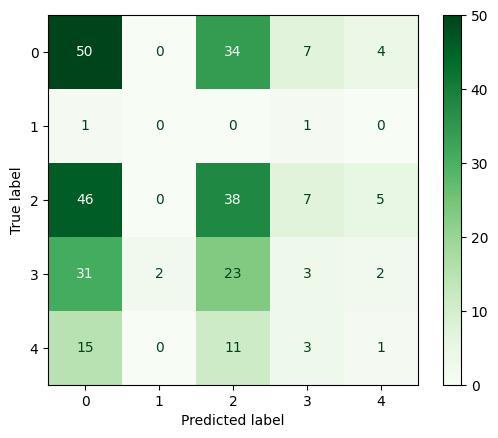

In [12]:
ConfusionMatrixDisplay.from_predictions(y_true=rating_y_true, y_pred=rating_y_pred, cmap='Greens')

In [13]:
train_predict = rating_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict,average='macro'))

Performance on the training set
Accuracy: 1.0
F1 score: 1.0


## Action

In [14]:
action_encoder = LabelEncoder()
train_y = action_encoder.fit_transform(train['action'])
action_y_true = action_encoder.transform(test['action'])

In [15]:
%%time
action_estimator = Pipeline([
    ('scaler', Normalizer()),
    ('clf', ProximityForest(n_jobs=-1, random_state=42))
])

action_estimator.fit(train_X, train_y)

CPU times: user 32min 10s, sys: 31.5 s, total: 32min 42s
Wall time: 32min 15s


Pipeline(steps=[('scaler', Normalizer()),
                ('clf', ProximityForest(n_jobs=-1, random_state=42))])

In [16]:
action_y_pred = action_estimator.predict(test_X)

In [17]:
print(classification_report(y_true=action_y_true, y_pred=action_y_pred))

              precision    recall  f1-score   support

           0       0.69      0.95      0.80       195
           1       0.44      0.08      0.13        89

    accuracy                           0.68       284
   macro avg       0.57      0.52      0.47       284
weighted avg       0.61      0.68      0.59       284



Performanace is worse than random.

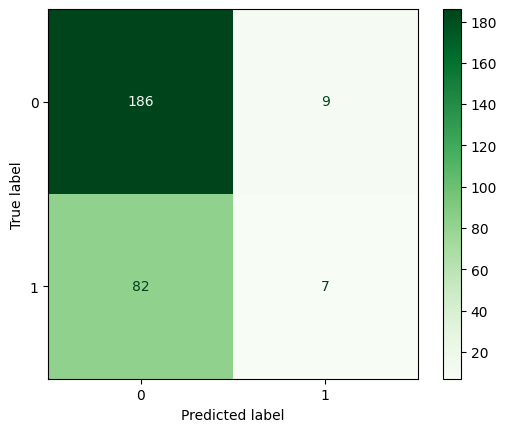

In [18]:
ConfusionMatrixDisplay.from_predictions(y_true=action_y_true, y_pred=action_y_pred, cmap='Greens')

In [19]:
train_predict = action_estimator.predict(train_X)
print("Performance on the training set")
print("Accuracy:", accuracy_score(y_true=train_y, y_pred=train_predict))
print("F1 score:", f1_score(y_true=train_y, y_pred=train_predict,average='macro'))

Performance on the training set
Accuracy: 1.0
F1 score: 1.0


Extreme overfitting on both tasks. Performance worse than the baseline.